In [1]:
# data management packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
from google.colab import drive
import matplotlib.dates as mdates

# Simulation
from statsmodels.tsa.arima_process import arma_generate_sample

# Step 1: Identification
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import arma_order_select_ic

# Step 2: Estimation
from statsmodels.tsa.arima.model import ARIMA

# Step 3: Diagnostics
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.api import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

Mounted at /content/drive


# **White Noise**

In [11]:
rng = np.random.default_rng(123)
n = 500
wn = rng.normal(0, 1, n)

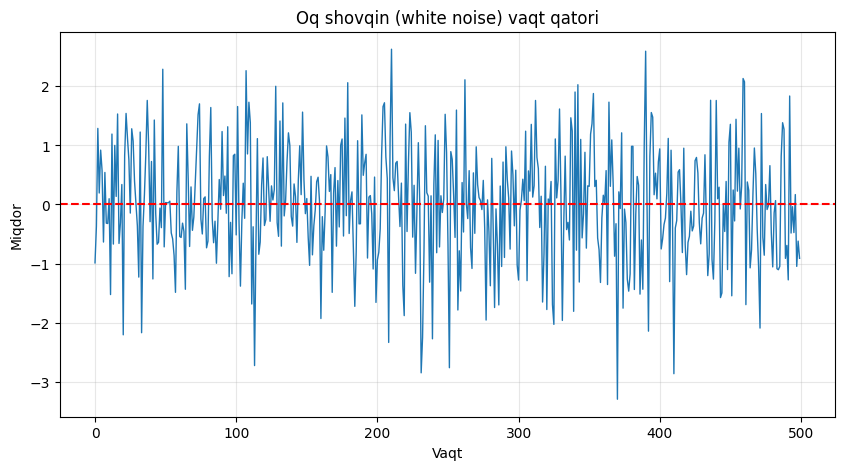

In [29]:
plt.figure(figsize = (10, 5))
plt.plot(wn, linewidth = 1.0)
plt.title('Oq shovqin (white noise) vaqt qatori')
plt.xlabel('Vaqt')
plt.ylabel('Miqdor')
plt.axhline(0, linestyle='dashed', color = 'red')
plt.grid(True, alpha = 0.3)
plt.show()

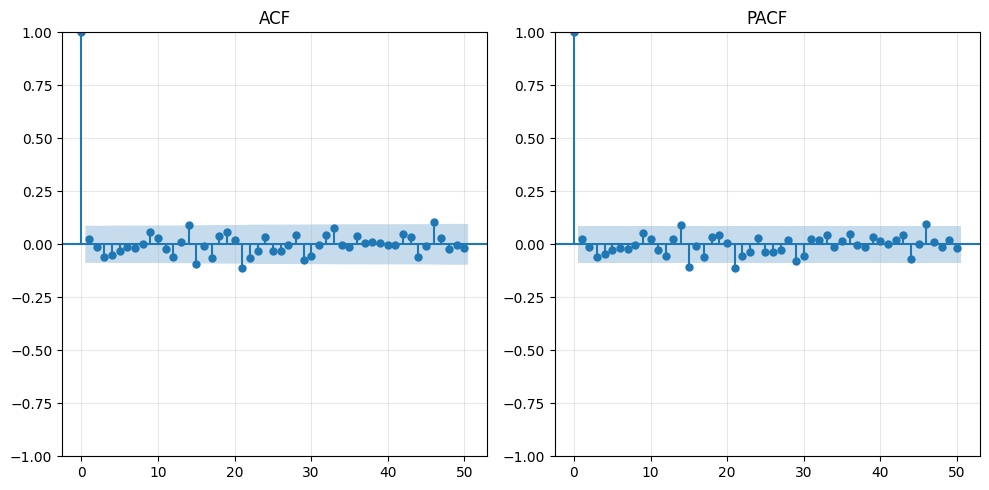

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
plot_acf(wn, lags = 50, ax = ax1)
plot_pacf(wn, lags = 50, ax = ax2)
ax1.set_title("ACF")
ax1.grid(True, alpha = 0.3)
ax2.set_title("PACF")
ax2.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

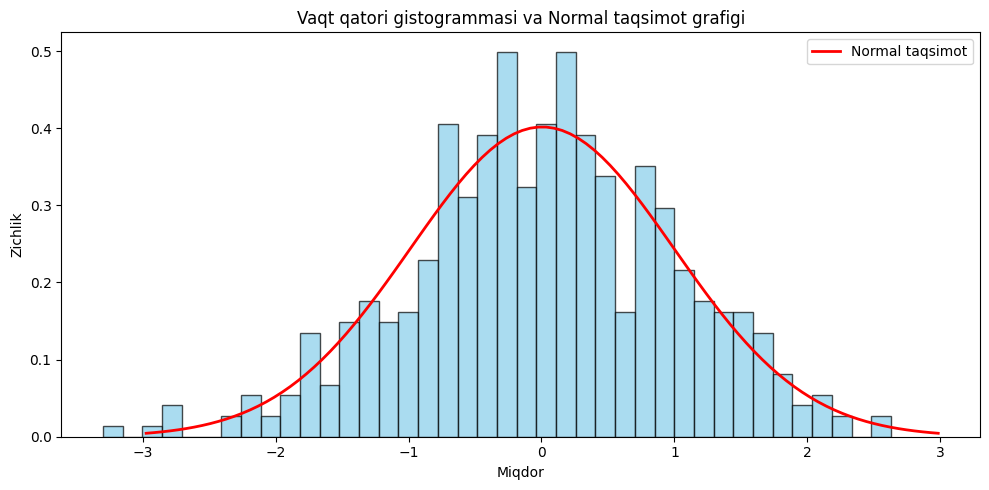

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(wn, bins=40, density=True,
        alpha=0.7, color='skyblue', edgecolor='black')
mu = np.mean(wn)
sigma = np.std(wn)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal taqsimot')
ax.set_title("Vaqt qatori gistogrammasi va Normal taqsimot grafigi", fontsize=12)
ax.set_xlabel("Miqdor")
ax.set_ylabel("Zichlik")
ax.legend()
plt.tight_layout()
plt.show()

# **MA(1) vaqt qatorlari**

In [15]:
def build_ma(theta, n = 500, mu = 0):
  errors = rng.normal(0, 1, n)
  ma1 = np.zeros(n)
  for t in range(n):
    if t == 0:
      ma1[t] = mu + errors[t]
    else:
      ma1[t] = mu + theta * errors[t - 1] + errors[t]
  return np.array(ma1)


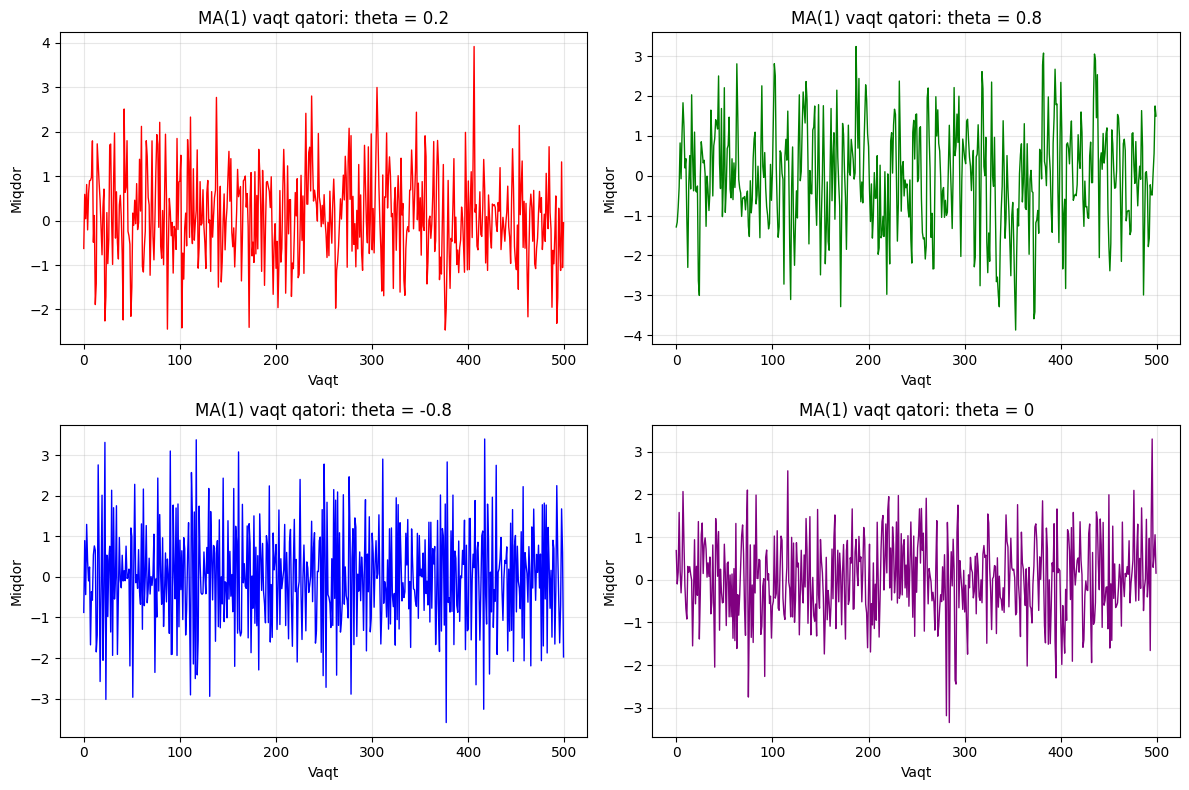

In [27]:
theta_values = [0.2, 0.8, -0.8, 0]

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()
color = ['red', 'green', 'blue', 'purple']

for i, theta in enumerate(theta_values):
  ma_series = build_ma(theta)
  axes[i].plot(ma_series, linewidth = 1.0, color = color[i])
  axes[i].set_title(f"MA(1) vaqt qatori: theta = {theta}")
  axes[i].set_xlabel("Vaqt")
  axes[i].set_ylabel("Miqdor")
  axes[i].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

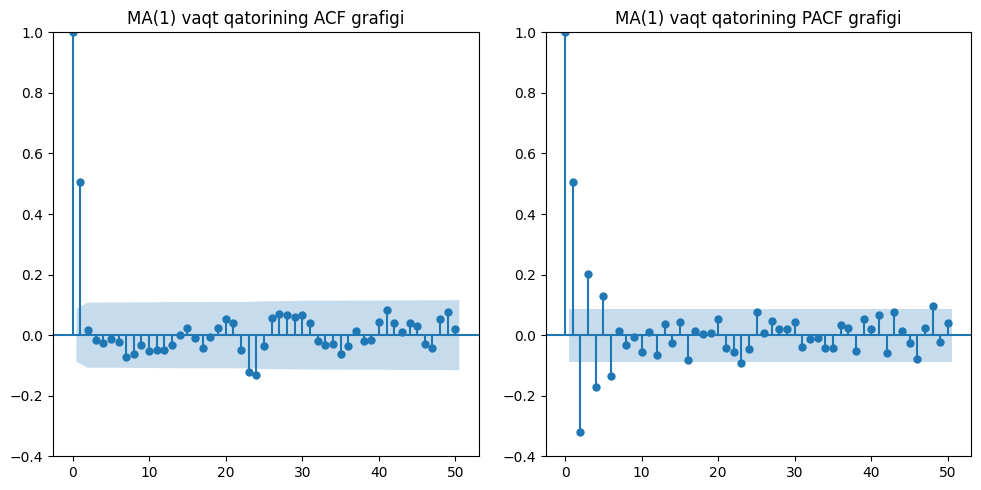

In [18]:
ma_example = build_ma(theta = 0.8)

figure, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
plot_acf(ma_example, lags = 50, ax = ax1)
ax1.set_title("MA(1) vaqt qatorining ACF grafigi", fontsize=12)

plot_pacf(ma_example, lags = 50, ax = ax2)
ax2.set_title("MA(1) vaqt qatorining PACF grafigi", fontsize=12)

plt.tight_layout()
ax1.set_ylim(-0.4, 1.0)
ax2.set_ylim(-0.4, 1.0)
plt.show()

# **AR(1) vaqt qatorlari**

In [19]:
def build_ar(phi, n = 200, c = 0):
  errors = rng.normal(0, 1, n)
  ar1 = np.zeros(n)
  for t in range(n):
    if t == 0:
      ar1[t] = c + phi * errors[t]
    else:
      ar1[t] = c + phi * ar1[t - 1] + errors[t]
  return np.array(ar1)

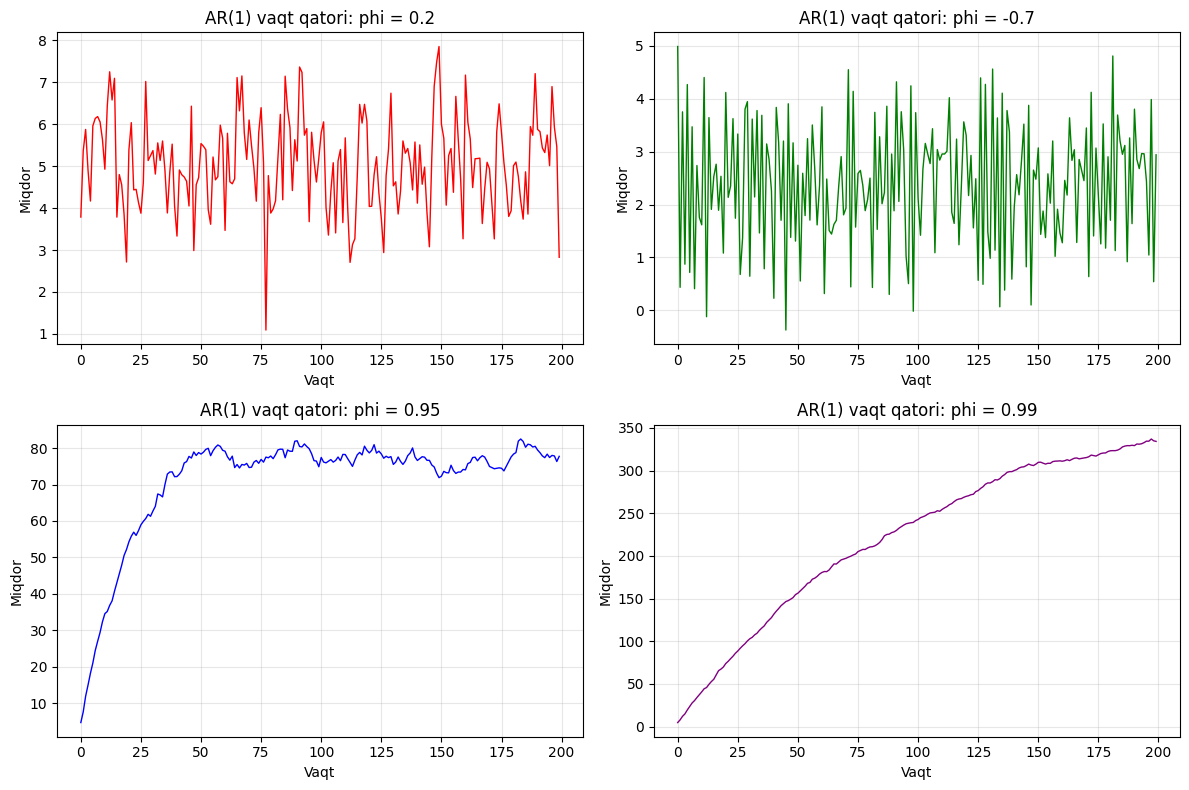

In [26]:
phi_values = [0.2, -0.7, 0.95, 0.99]

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()
color = ['red', 'green', 'blue', 'purple']

for i, phi in enumerate(phi_values):
  ar_series = build_ar(phi, n = 200, c = 4)
  axes[i].plot(ar_series, linewidth = 1.0, color = color[i])
  axes[i].set_title(f"AR(1) vaqt qatori: phi = {phi}")
  axes[i].set_xlabel("Vaqt")
  axes[i].set_ylabel("Miqdor")
  axes[i].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()


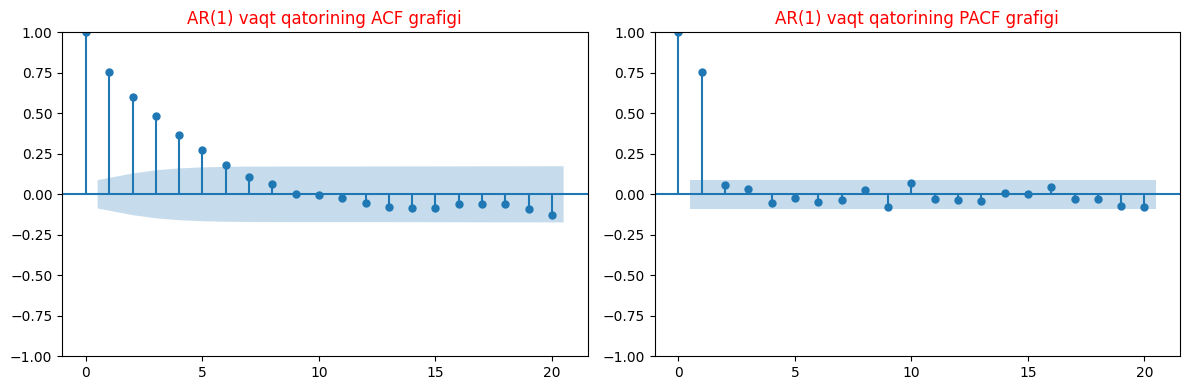

In [23]:
ar_example = build_ar(phi = 0.7, n = 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ar_example, ax=ax1, lags=20)
plot_pacf(ar_example, ax=ax2, lags=20)
ax1.set_title("AR(1) vaqt qatorining ACF grafigi", fontsize=12, color = 'red')
ax2.set_title("AR(1) vaqt qatorining PACF grafigi", fontsize=12, color = 'red')
plt.tight_layout()
plt.show()

# **ARMA(2, 2) vaqt qatorlari**

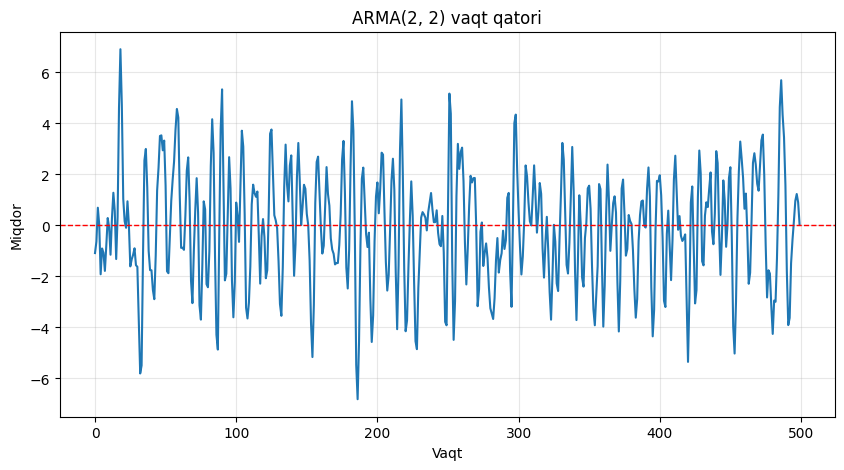

In [25]:
ar = np.array([1, -0.8, 0.6])
ma = np.array([1, 0.7, 0.4])

np.random.seed(123)
y = arma_generate_sample(ar = ar, ma = ma, nsample = 500)
y = pd.Series(y)

plt.figure(figsize = (10, 5))
y.plot();
plt.xlabel('Vaqt')
plt.ylabel('Miqdor')
plt.title('ARMA(2, 2) vaqt qatori')
plt.grid(True, alpha = 0.3)
plt.axhline(0, ls = 'dashed', c = 'red', lw = 1.0)
plt.show()

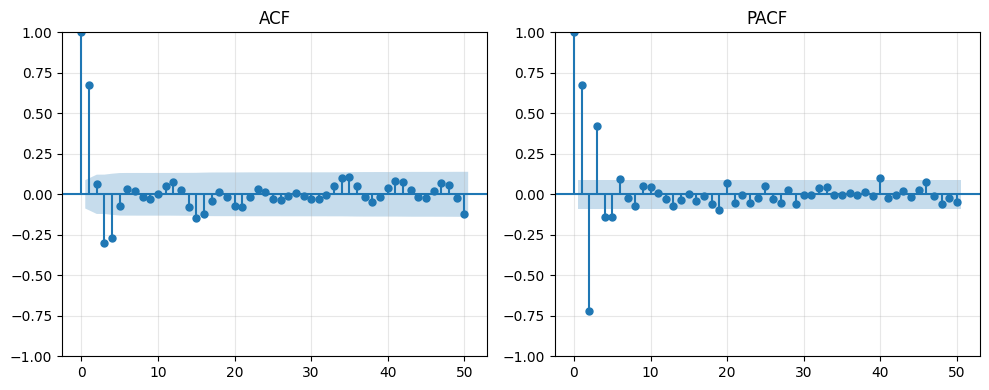

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))
plot_acf(y, lags = 50, ax = ax1)
plot_pacf(y, lags = 50, ax = ax2)
ax1.set_title("ACF")
ax2.set_title("PACF")
plt.tight_layout()
ax1.grid(True, alpha = 0.3)
ax2.grid(True, alpha = 0.3)
plt.show()

# **Real Ma'lumot bilan ishlash**



# **Birinchi amaliy mashg'ulot uchun 2000 yil va 2025 yil oralig'idagi O'zbekiston uchun Is'temol narxlari indeksi (INI) ma'lumotlari foydalaniladi.**


## Amalga oshiriladigan bosqichlar:


### 1	INI ma'lumotlarini yuklash va grafigini yasash


### 2	Transformatsiya amalga oshirish


### 3	Choraklik inflyatsiya darajasini hisoblash (QoQ)


### 4	ADF va KPSS testlari yordamida inflyatsiya darajasini statsionarlikka tekshirish


### 5	Inflyatsiya darajasi uchun model tanlash maqsadida ACF/PACF grafiklarini yashash


### 6	5-bosqichda tanlab olingan modellarni baholash


### 7	Ma'lumotlar kriteriya bo'yicha "eng yaxshi" modelni tanlab olish


### 8	Tanlab olingan "eng yaxshi" modeldan olingan xatoliklar diagnostikasi


### 9	Agar diagnostika bosqichi "yaxshi" o'tsa prognozlashni amalga oshirish

In [37]:
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/uz.data.xlsx', usecols='B') # fayl joylashuviga qarab yo'lni o'zgartirish kerak
date_index = pd.date_range(start = '2000', periods = 104, freq = 'Q')
data.index = date_index
data.head()

,cpi
2000-03-31,105.032106
2000-06-30,108.554011
2000-09-30,116.155520
2000-12-31,125.051941
2001-03-31,131.655918


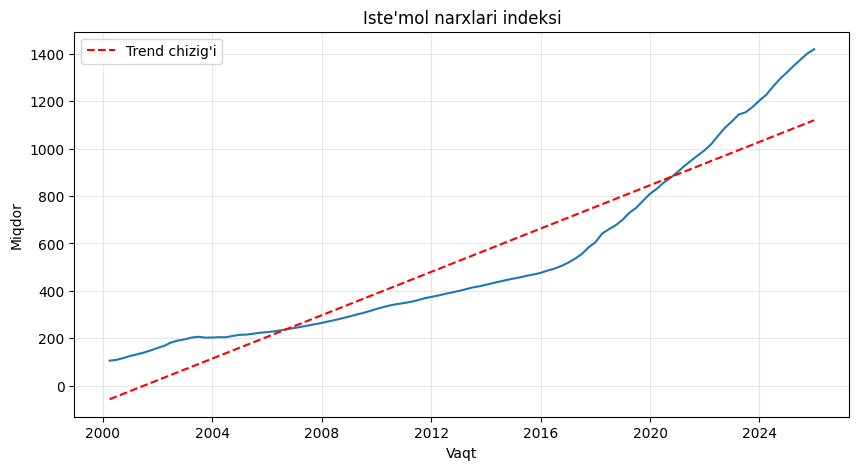

In [40]:
fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(data.index, data['cpi'])
ax.set_title('Iste\'mol narxlari indeksi')
ax.set_xlabel('Vaqt')
ax.set_ylabel('Miqdor')

x_num = mdates.date2num(data.index)
y = data['cpi']
z = np.polyfit(x_num, y, 1)
p = np.poly1d(z)

ax.plot(data.index, p(x_num), "r--", label='Trend chizig\'i')
plt.legend()

ax.grid(True, alpha = 0.3)

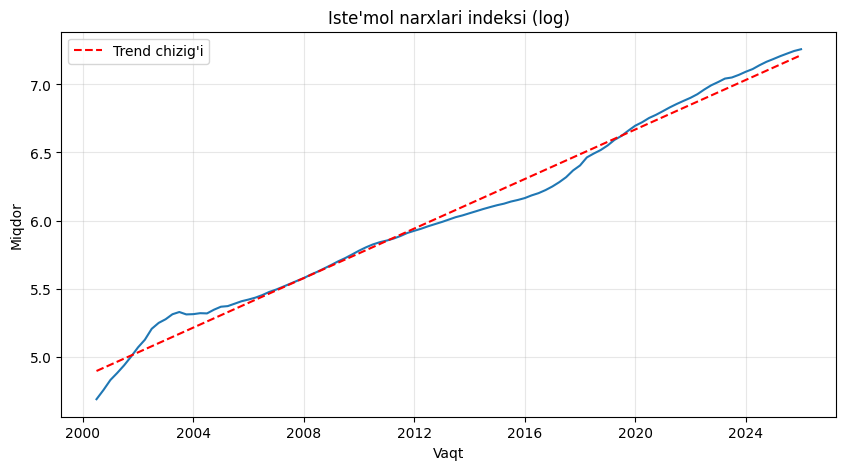

In [100]:
data['log_cpi'] = np.log(data['cpi'])

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(data.index, data['log_cpi'])
ax.set_title('Iste\'mol narxlari indeksi (log)')
ax.set_xlabel('Vaqt')
ax.set_ylabel('Miqdor')

x_num = mdates.date2num(data.index)
y = data['log_cpi']
z = np.polyfit(x_num, y, 1)
p = np.poly1d(z)

ax.plot(data.index, p(x_num), "r--", label='Trend chizig\'i')
plt.legend()

ax.grid(True, alpha = 0.3)

In [101]:
data['inflation'] = data['log_cpi'].diff()*400
data.head()
data = data.dropna()

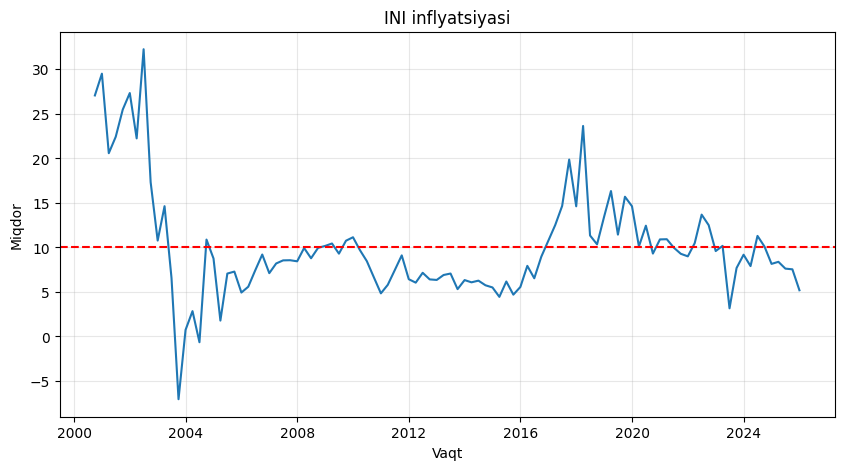

In [102]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(data.index, data['inflation'])
mu = np.mean(data['inflation'])
ax.set_title('INI inflyatsiyasi')
ax.set_xlabel('Vaqt')
ax.set_ylabel('Miqdor')
ax.grid(True, alpha = 0.3)
ax.axhline(y = mu, color = 'r', linestyle = '--')

plt.show()


In [103]:
def stationarity_test(timeseries):
    print("KPSS va ADF testlarining natijalari:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    adftest = adfuller(timeseries, autolag='AIC')
    output = pd.DataFrame(
        {'KPSS Test': [kpsstest[0], kpsstest[1], kpsstest[2],
                       kpsstest[3]['10%'], kpsstest[3]['5%'], kpsstest[3]['1%']],
         'ADF Test': [adftest[0], adftest[1], adftest[2],
                      adftest[4]['10%'], adftest[4]['5%'], adftest[4]['1%']]},
        index=["Test statistikasi", "p-value", "Laglar", "Kritik miqdor (10%)",
               "Kritik miqdor(5%)", "Kritik miqdor (1%)"]
    )
    print(np.round(output, 3))


stationarity_test(data['inflation'])

KPSS va ADF testlarining natijalari:
                     KPSS Test  ADF Test
Test statistikasi        0.188    -4.291
p-value                  0.100     0.000
Laglar                   5.000     5.000
Kritik miqdor (10%)      0.347    -2.583
Kritik miqdor(5%)        0.463    -2.892
Kritik miqdor (1%)       0.739    -3.500


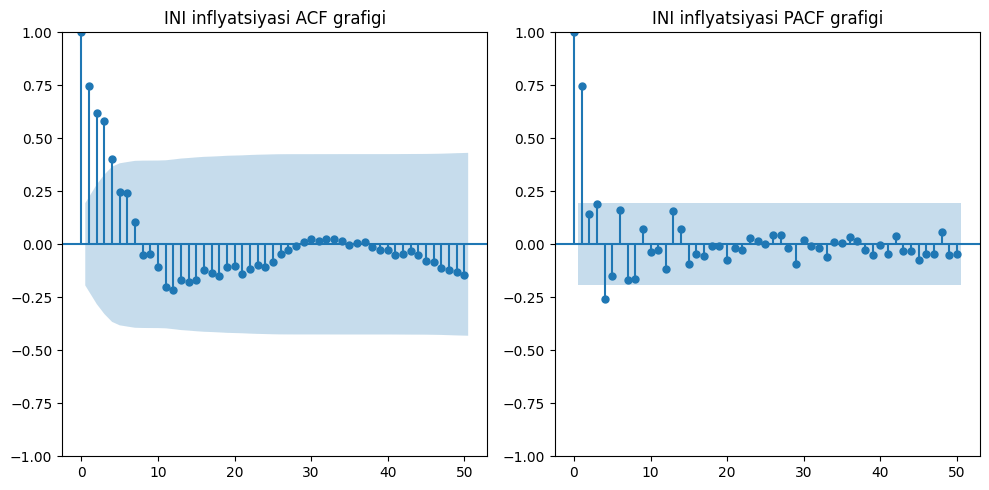

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

plot_acf(data['inflation'], lags = 50, ax = ax1)
ax1.set_title("INI inflyatsiyasi ACF grafigi", fontsize=12)

plot_pacf(data['inflation'], lags = 50, ax = ax2)
ax2.set_title("INI inflyatsiyasi PACF grafigi", fontsize=12)

plt.tight_layout()
plt.show()

In [107]:
model_ar1 = ARIMA(data['inflation'], order=(1, 0, 0))
ar1 = model_ar1.fit()

print(ar1.summary())
print(f"\nAIC: {ar1.aic:.2f}")
print(f"BIC: {ar1.bic:.2f}")

                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  102
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -283.063
Date:                Wed, 08 Apr 2026   AIC                            572.126
Time:                        06:28:42   BIC                            580.001
Sample:                    09-30-2000   HQIC                           575.315
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5278      1.870      5.630      0.000       6.863      14.193
ar.L1          0.8018      0.041     19.347      0.000       0.721       0.883
sigma2        14.9138      1.354     11.018      0.0

In [108]:
model_arma11 = ARIMA(data['inflation'], order=(1, 0, 1))
arma11 = model_arma11.fit()

print(arma11.summary())
print(f"\nAIC: {arma11.aic:.2f}")
print(f"BIC: {arma11.bic:.2f}")

                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  102
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -279.827
Date:                Wed, 08 Apr 2026   AIC                            567.654
Time:                        06:28:44   BIC                            578.154
Sample:                    09-30-2000   HQIC                           571.906
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.2346      3.060      3.671      0.000       5.236      17.233
ar.L1          0.9204      0.040     23.155      0.000       0.843       0.998
ma.L1         -0.3046      0.086     -3.525      0.0

In [109]:
model_ar2 = ARIMA(data['inflation'], order=(2, 0, 0))
ar2 = model_ar2.fit()

print(ar2.summary())
print(f"\nAIC: {ar2.aic:.2f}")
print(f"BIC: {ar2.bic:.2f}")

                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  102
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -280.378
Date:                Wed, 08 Apr 2026   AIC                            568.755
Time:                        06:28:47   BIC                            579.255
Sample:                    09-30-2000   HQIC                           573.007
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.9941      2.748      4.001      0.000       5.608      16.380
ar.L1          0.6285      0.060     10.546      0.000       0.512       0.745
ar.L2          0.2370      0.067      3.531      0.0

In [110]:
comparison_data = {
    "Model": ["AR(1)", "ARMA(1,1)", "AR(2)"],
    "AIC": [ar1.aic, arma11.aic, ar2.aic],
    "BIC": [ar1.bic, arma11.bic, ar2.bic],
    "Log-Likelihood": [ar1.llf, arma11.llf, ar2.llf],
    "Parameterlar": [len(ar1.params), len(arma11.params), len(ar2.params)]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2)

comparison_df

,Model,AIC,BIC,Log-Likelihood,Parameterlar
0,AR(1),572.13,580.00,-283.06,3
1,"ARMA(1,1)",567.65,578.15,-279.83,4
2,AR(2),568.76,579.26,-280.38,4


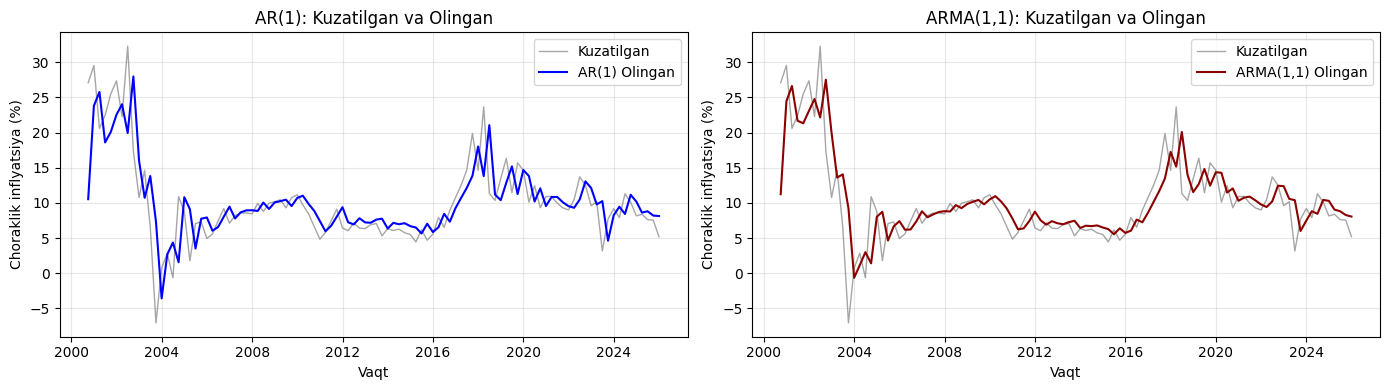

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))


ax1.plot(data['inflation'], linewidth=1, color='gray', alpha=0.7, label='Kuzatilgan')
ax1.plot(ar1.fittedvalues, linewidth=1.5, color='blue', label='AR(1) Olingan')
ax1.set_title("AR(1): Kuzatilgan va Olingan", fontsize=12)
ax1.set_xlabel("Vaqt")
ax1.set_ylabel("Choraklik inflyatsiya (%)")
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(data['inflation'], linewidth=1, color='gray', alpha=0.7, label='Kuzatilgan')
ax2.plot(arma11.fittedvalues, linewidth=1.5, color='darkred', label='ARMA(1,1) Olingan')
ax2.set_title("ARMA(1,1): Kuzatilgan va Olingan", fontsize=12)
ax2.set_xlabel("Vaqt")
ax2.set_ylabel("Choraklik inflyatsiya (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [114]:
residuals = arma11.resid
residuals = residuals.dropna()

print("\n" + "=" * 70)
print("ARMA(1, 1) modeli uchun xatoliklar diagnostikasi")
print("=" * 70)
print(f"Kuzatuv hajmi: {len(residuals)}")
print(f"Xatoliklar o\'rtacha miqdori: {residuals.mean():.6f}")
print(f"Variyatsiya darajasi (sigma²): {np.var(residuals):.6f}")


ARMA(1, 1) modeli uchun xatoliklar diagnostikasi
Kuzatuv hajmi: 102
Xatoliklar o'rtacha miqdori: -0.247545
Variyatsiya darajasi (sigma²): 15.666872


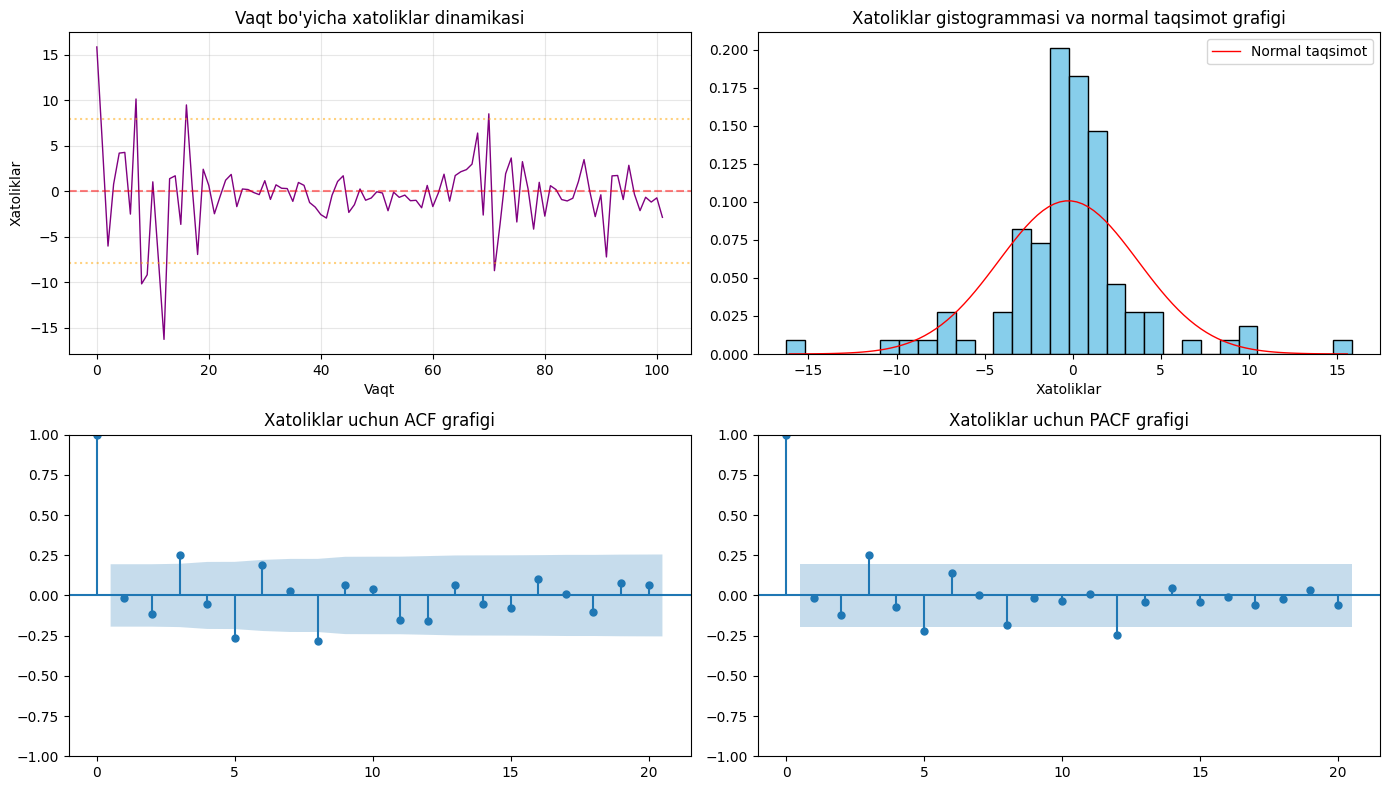

In [115]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes.flatten()

ax[0].plot(residuals.values, linewidth=1, color='purple')
ax[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax[0].axhline(y=2*np.std(residuals), color='orange', linestyle=':', alpha=0.5)
ax[0].axhline(y=-2*np.std(residuals), color='orange', linestyle=':', alpha=0.5)
ax[0].set_title("Vaqt bo\'yicha xatoliklar dinamikasi", fontsize=12)
ax[0].set_xlabel("Vaqt")
ax[0].set_ylabel("Xatoliklar")
ax[0].grid(True, alpha=0.3)

ax[1].hist(residuals, bins=30, edgecolor='black', color='skyblue', density=True)
mu, std = np.mean(residuals), np.std(residuals)
x = np.linspace(mu - 4*std, mu + 4*std, 100)
ax[1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=1, label='Normal taqsimot')
ax[1].set_title("Xatoliklar gistogrammasi va normal taqsimot grafigi", fontsize=12)
ax[1].set_xlabel("Xatoliklar")
ax[1].legend()

plot_acf(residuals, ax=ax[2], lags=20, alpha=0.05)
ax[2].set_title("Xatoliklar uchun ACF grafigi", fontsize=12)

plot_pacf(residuals, ax=ax[3], lags=20, alpha=0.05, method='ywm')
ax[3].set_title("Xatoliklar uchun PACF grafigi", fontsize=12)

plt.tight_layout()
plt.show()

In [116]:
print("\n" + "=" * 50)
print("Avtokorrelyatsiya uchun test: LYUNG-BOKS TESTI")
print("=" * 50)

lb_results = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
print(lb_results.to_string())

print("-" * 50)


Avtokorrelyatsiya uchun test: LYUNG-BOKS TESTI
      lb_stat  lb_pvalue
5   16.047855   0.006709
10  29.956297   0.000871
15  37.233794   0.001170
20  41.264937   0.003444
--------------------------------------------------


In [117]:
print("\n" + "=" * 35)
print("NORMAL TAQSIMOT UCHUN TESTLAR")
print("=" * 35)

jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")

print("-" * 35)

shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_pvalue:.4f}")

print("-" * 35)

residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)
ks_stat, ks_pvalue = stats.kstest(residuals_std, 'norm')
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.4f}")

print("-" * 35)

norm_test = stats.normaltest(residuals)
print(f"Test statistic: {norm_test[0]:.4f}")
print(f"p-value: {norm_test[1]:.4f}")

print("-" * 35)


NORMAL TAQSIMOT UCHUN TESTLAR
Jarque-Bera statistic: 96.1909
p-value: 0.0000
-----------------------------------
Shapiro-Wilk statistic: 0.8912
p-value: 0.0000
-----------------------------------
KS statistic: 0.1355
p-value: 0.0429
-----------------------------------
Test statistic: 18.2738
p-value: 0.0001
-----------------------------------


In [118]:
p_values = [lb_results['lb_pvalue'].iloc[0], lb_results['lb_pvalue'].iloc[1],
            lb_results['lb_pvalue'].iloc[2], lb_results['lb_pvalue'].iloc[3],
            jb_pvalue, shapiro_pvalue, ks_pvalue, norm_test[1]]

test_results = {
    "Test": ["Lyung-Boks (lag 5)", "Lyung-Boks (lag 10)", "Lyung-Boks (lag 15)",
             "Lyung-Boks (lag 20)", "Jarque-Bera", "Shapiro-Wilk",
             "Kolmogorov-Smirnov", "Normality Test"],
    "p-value": p_values,
    "Xulosa": ["Rad etish" if p < 0.05 else "Rad etmaslik" for p in p_values]
}

test_results = np.round(pd.DataFrame(test_results), 6)
test_results

,Test,p-value,Xulosa
0,Lyung-Boks (lag 5),0.006709,Rad etish
1,Lyung-Boks (lag 10),0.000871,Rad etish
2,Lyung-Boks (lag 15),0.001170,Rad etish
3,Lyung-Boks (lag 20),0.003444,Rad etish
4,Jarque-Bera,0.000000,Rad etish
5,Shapiro-Wilk,0.000000,Rad etish
6,Kolmogorov-Smirnov,0.042913,Rad etish
7,Normality Test,0.000108,Rad etish


In [119]:
horizons = {
    "Qisqa muddat": 4,
    "O\'rta muddat": 8,
    "Uzoq muddat": 12
}

selected_horizon = "Qisqa muddat"
h = horizons[selected_horizon]

In [120]:
last_date = max(data.index)
forecast_dates = pd.date_range(start=last_date + pd.offsets.QuarterEnd(),
                                periods=h, freq='Q')

print(f"Forecast period: {forecast_dates[0].strftime("%Y-%m-%d")} to {forecast_dates[-1].strftime("%Y-%m-%d")}")

Forecast period: 2026-03-31 to 2026-12-31


In [121]:
forecast_model = ARIMA(data['inflation'], order=(1, 0, 1))
forecast_fitted = forecast_model.fit()

forecast_result = forecast_fitted.get_forecast(steps=h)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()  # 95% confidence interval

print("\nFORECAST TABLE (Quarterly Inflation %):")
print("-" * 60)
print(f"{'Period':<15}{'Forecast (%)':<15} {'Lower 95%':<12} {'Upper 95%':<12}")
print("-" * 60)

for i in range(h):
    period_str = forecast_dates[i].strftime("%Y-%m-%d")
    print(f"{period_str}     {forecast_mean.iloc[i]:<15.2f} {forecast_ci.iloc[i, 0]:<12.2f} {forecast_ci.iloc[i, 1]:<12.2f}")


FORECAST TABLE (Quarterly Inflation %):
------------------------------------------------------------
Period         Forecast (%)    Lower 95%    Upper 95%   
------------------------------------------------------------
2026-03-31     6.55            -0.78        13.87       
2026-06-30     6.92            -1.68        15.52       
2026-09-30     7.26            -2.29        16.81       
2026-12-31     7.58            -2.71        17.86       


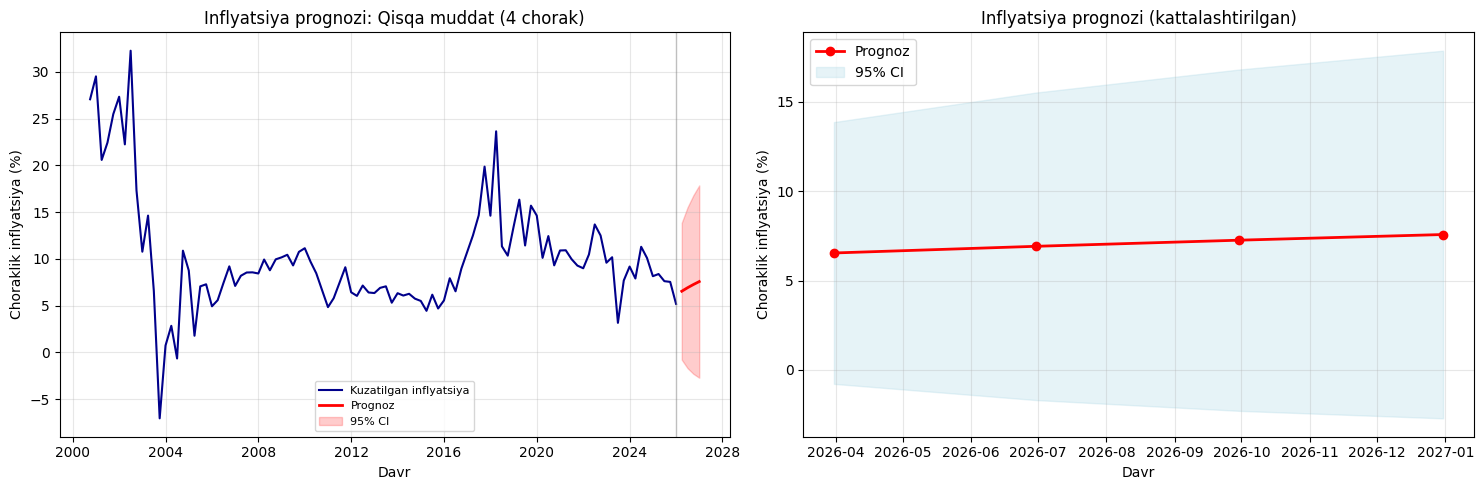

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].plot(data.index, data['inflation'],
             linewidth=1.5, color='darkblue', label='Kuzatilgan inflyatsiya')
axes[0].plot(forecast_dates, forecast_mean,
             linewidth=2, color='red', label='Prognoz')
axes[0].fill_between(forecast_dates,
                     forecast_ci.iloc[:, 0],
                     forecast_ci.iloc[:, 1],
                     color='red', alpha=0.2, label='95% CI')
axes[0].axvline(x=data.index[-1], color='gray', linestyle='-', alpha=0.5, linewidth=1)

axes[0].set_title(f"Inflyatsiya prognozi: {selected_horizon} ({h} chorak)", fontsize=12)
axes[0].set_xlabel("Davr")
axes[0].set_ylabel("Choraklik inflyatsiya (%)")
axes[0].legend(loc='lower center', fontsize = 8)
axes[0].grid(True, alpha=0.3)



axes[1].plot(forecast_dates, forecast_mean, 'ro-', linewidth=2, label='Prognoz')
axes[1].fill_between(forecast_dates,
                      forecast_ci.iloc[:, 0],
                      forecast_ci.iloc[:, 1],
                      color='lightblue', alpha=0.3, label='95% CI')

axes[1].set_title(f"Inflyatsiya prognozi (kattalashtirilgan)", fontsize=12)
axes[1].set_xlabel("Davr")
axes[1].set_ylabel("Choraklik inflyatsiya (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Ikkinchi amaliy mashg'ulot uchun 1880 yil va 1985 yil oralig'idagi yillik o'rtacha harorat bo'yicha olingan ma'lumotlar foydalaniladi.**


## Amalga oshiriladigan bosqichlar birinchi amaliy mashg'ulot bilan bir xil.


In [123]:
tep = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/air.temp.csv',
                  header = None)
dates = pd.date_range('1880-12', periods = len(tep), freq = 'A-DEC')
tep.index = dates
tepts = pd.Series(tep[0])

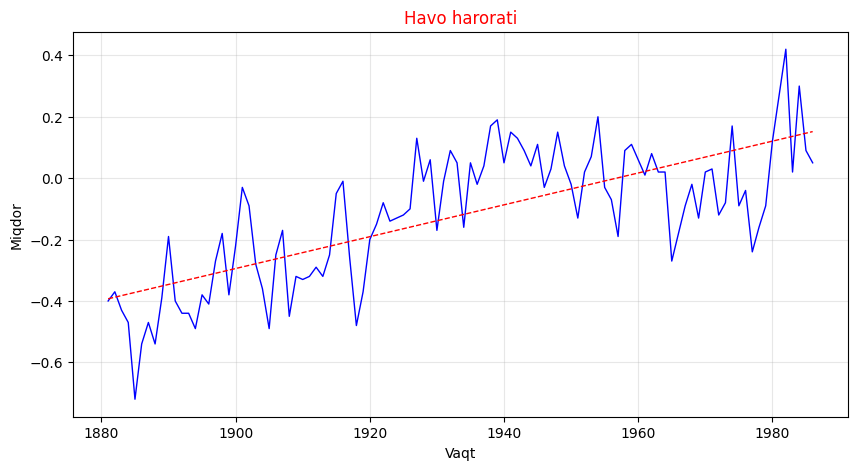

In [124]:
fig = plt.figure(figsize = (10, 5))
plt.plot(tepts, color = 'b', lw = 1.0)

dnums = mdates.date2num(tepts.index)
z = np.polyfit(dnums, tepts, 1)
p = np.poly1d(z)
plt.plot(tepts.index, p(dnums), 'r--', lw = 1.0)

plt.title('Havo harorati', color = 'red')
plt.xlabel('Vaqt')
plt.ylabel('Miqdor')

plt.grid(True, alpha = 0.3)
plt.show()

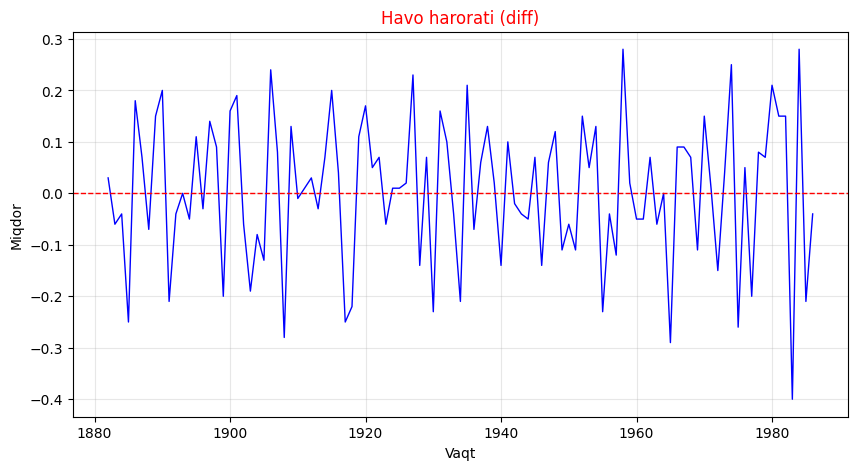

In [125]:
dtepts = tepts.diff()
dtepts = dtepts.dropna()

fig = plt.figure(figsize = (10, 5))
plt.plot(dtepts, color = 'b', lw = 1.0)
plt.axhline(0, ls = 'dashed', c = 'red', lw = 1.0)

plt.title('Havo harorati (diff)', color = 'red')
plt.xlabel('Vaqt')
plt.ylabel('Miqdor')

plt.grid(True, alpha = 0.3)
plt.show()

In [126]:
stationarity_test(dtepts)

KPSS va ADF testlarining natijalari:
                     KPSS Test  ADF Test
Test statistikasi        0.083    -6.437
p-value                  0.100     0.000
Laglar                  12.000     6.000
Kritik miqdor (10%)      0.347    -2.583
Kritik miqdor(5%)        0.463    -2.892
Kritik miqdor (1%)       0.739    -3.499


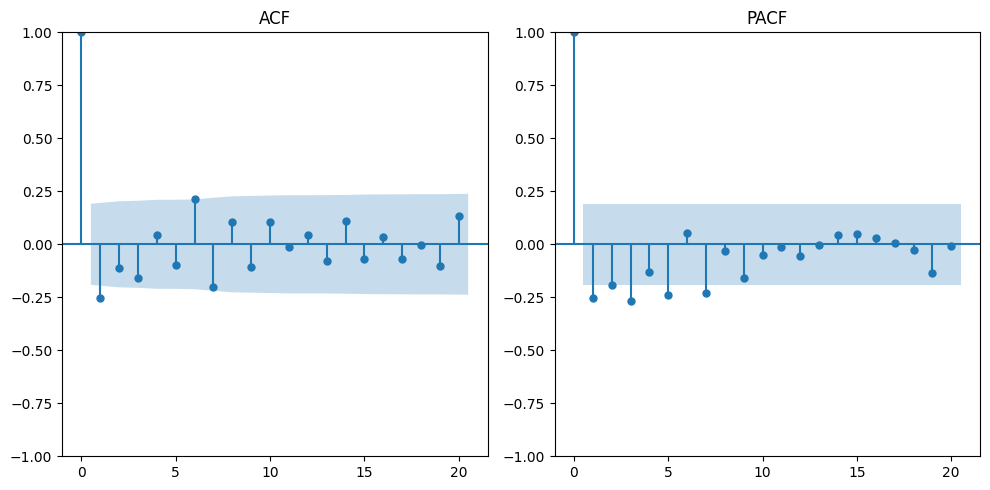

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

plot_acf(dtepts, lags = 20, ax = ax1)
ax1.set_title("ACF", fontsize=12)

plot_pacf(dtepts, lags = 20, ax = ax2)
ax2.set_title("PACF", fontsize=12)

plt.tight_layout()
plt.show()

In [128]:
inf = arma_order_select_ic(dtepts, max_ar = 7,
                           max_ma = 7, ic = ['aic', 'bic', 'hqic'], trend = 'c')

In [129]:
print(f"AIC tanlovi: {int(inf.aic_min_order[0]), int(inf.aic_min_order[1])}")
print(f"BIC tanlovi: {int(inf.bic_min_order[0]), int(inf.bic_min_order[1])}")
print(f"HQIC tanlovi: {int(inf.hqic_min_order[0]), int(inf.hqic_min_order[1])}")

AIC tanlovi: (1, 3)
BIC tanlovi: (1, 1)
HQIC tanlovi: (1, 3)


In [130]:
dtept_arma11 = ARIMA(dtepts, order = (1,0,1), trend = 'c').fit()
print(dtept_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  105
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  69.356
Date:                Wed, 08 Apr 2026   AIC                           -130.713
Time:                        06:37:06   BIC                           -120.097
Sample:                    12-31-1881   HQIC                          -126.411
                         - 12-31-1985                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0053      0.003      2.121      0.034       0.000       0.010
ar.L1          0.3925      0.107      3.683      0.000       0.184       0.601
ma.L1         -0.8876      0.061    -14.515      0.0

In [131]:
dtept_residuals = dtept_arma11.resid
dtept_residuals = dtept_residuals.dropna()

print("\n" + "=" * 70)
print("ARMA(1, 1) modeli uchun xatoliklar diagnostikasi")
print("=" * 70)
print(f"Kuzatuv hajmi: {len(dtept_residuals)}")
print(f"Xatoliklar o\'rtacha miqdori: {dtept_residuals.mean():.6f}")
print(f"Vartiyasiya miqdori (sigma²): {np.var(dtept_residuals):.6f}")


ARMA(1, 1) modeli uchun xatoliklar diagnostikasi
Kuzatuv hajmi: 105
Xatoliklar o'rtacha miqdori: -0.000987
Vartiyasiya miqdori (sigma²): 0.015587


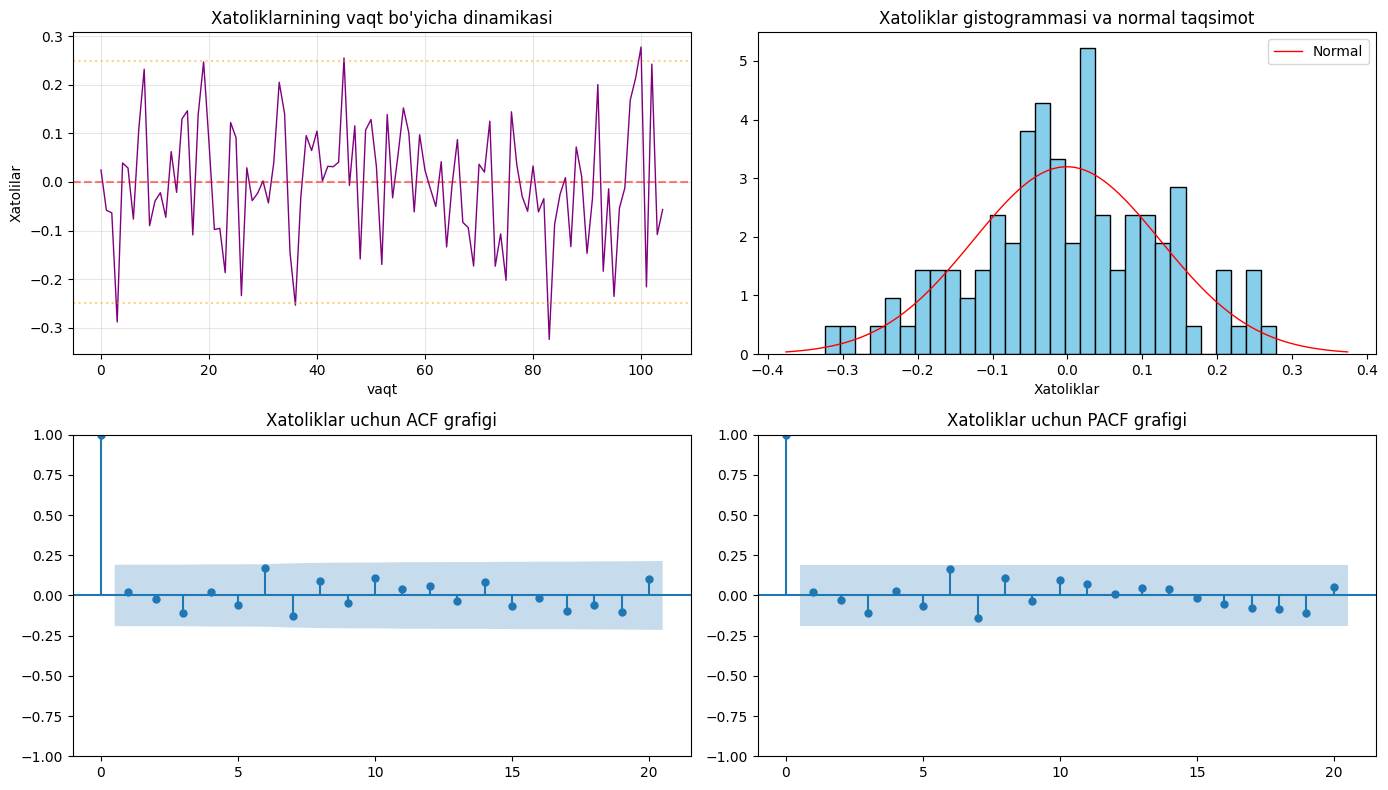

In [148]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes.flatten()

ax[0].plot(dtept_residuals.values, linewidth=1, color='purple')
ax[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax[0].axhline(y=2*np.std(dtept_residuals), color='orange', linestyle=':', alpha=0.5)
ax[0].axhline(y=-2*np.std(dtept_residuals), color='orange', linestyle=':', alpha=0.5)
ax[0].set_title("Xatoliklarnining vaqt bo\'yicha dinamikasi", fontsize=12)
ax[0].set_xlabel("vaqt")
ax[0].set_ylabel("Xatolilar")
ax[0].grid(True, alpha=0.3)

ax[1].hist(dtept_residuals, bins=30, edgecolor='black', color='skyblue', density=True)
mu, std = np.mean(dtept_residuals), np.std(dtept_residuals)
x = np.linspace(mu - 3*std, mu + 3*std, 100)
ax[1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=1, label='Normal')
ax[1].set_title("Xatoliklar gistogrammasi va normal taqsimot", fontsize=12)
ax[1].set_xlabel("Xatoliklar")
ax[1].legend()

plot_acf(dtept_residuals, ax=ax[2], lags=20, alpha=0.05)
ax[2].set_title("Xatoliklar uchun ACF grafigi", fontsize=12)

plot_pacf(dtept_residuals, ax=ax[3], lags=20, alpha=0.05, method='ywm')
ax[3].set_title("Xatoliklar uchun PACF grafigi", fontsize=12)

plt.tight_layout()
plt.show()

In [135]:
print("\n" + "=" * 50)
print("Avtokorrelyatsiya uchun test: LYUNG-BOKS TESTI")
print("=" * 50)

lb_results = acorr_ljungbox(dtept_residuals, lags=[5, 10, 15, 20], return_df=True)
print(lb_results.to_string())

print("-" * 50)


Avtokorrelyatsiya uchun test: LYUNG-BOKS TESTI
      lb_stat  lb_pvalue
5    1.865704   0.867398
10   9.716417   0.465715
15  11.856766   0.689837
20  16.333810   0.695711
--------------------------------------------------


In [136]:
print("\n" + "=" * 35)
print("NORMAL TAQSIMOT UCHUN TESTLAR")
print("=" * 35)

jb_stat, jb_pvalue = stats.jarque_bera(dtept_residuals)
print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")

print("-" * 35)

shapiro_stat, shapiro_pvalue = stats.shapiro(dtept_residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_pvalue:.4f}")

print("-" * 35)

residuals_std = (dtept_residuals - np.mean(dtept_residuals)) / np.std(dtept_residuals)
ks_stat, ks_pvalue = stats.kstest(residuals_std, 'norm')
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.4f}")

print("-" * 35)

norm_test = stats.normaltest(dtept_residuals)
print(f"Test statistic: {norm_test[0]:.4f}")
print(f"p-value: {norm_test[1]:.4f}")

print("-" * 35)


NORMAL TAQSIMOT UCHUN TESTLAR
Jarque-Bera statistic: 0.3465
p-value: 0.8409
-----------------------------------
Shapiro-Wilk statistic: 0.9931
p-value: 0.8760
-----------------------------------
KS statistic: 0.0516
p-value: 0.9289
-----------------------------------
Test statistic: 0.2112
p-value: 0.8998
-----------------------------------


In [137]:
p_values = [lb_results['lb_pvalue'].iloc[0], lb_results['lb_pvalue'].iloc[1],
            lb_results['lb_pvalue'].iloc[2], lb_results['lb_pvalue'].iloc[3],
            jb_pvalue, shapiro_pvalue, ks_pvalue, norm_test[1]]

test_results = {
    "Test": ["Lyung-Boks (lag 5)", "Lyung-Boks (lag 10)", "Lyung-Boks (lag 15)",
             "Lyung-Boks (lag 20)", "Jarque-Bera", "Shapiro-Wilk",
             "Kolmogorov-Smirnov", "Normality Test"],
    "p-value": p_values,
    "Xulosa": ["Rad etish" if p < 0.05 else "Rad etmaslik" for p in p_values]
}

test_results = np.round(pd.DataFrame(test_results), 6)
test_results

,Test,p-value,Xulosa
0,Lyung-Boks (lag 5),0.867398,Rad etmaslik
1,Lyung-Boks (lag 10),0.465715,Rad etmaslik
2,Lyung-Boks (lag 15),0.689837,Rad etmaslik
3,Lyung-Boks (lag 20),0.695711,Rad etmaslik
4,Jarque-Bera,0.840947,Rad etmaslik
5,Shapiro-Wilk,0.876050,Rad etmaslik
6,Kolmogorov-Smirnov,0.928899,Rad etmaslik
7,Normality Test,0.899783,Rad etmaslik


In [138]:
horizons = {
    "Qisqa muddat": 5,
    "O\'rta muddat": 10,
    "Uzoq muddat": 15
}

selected_horizon = "Uzoq muddat"
h = horizons[selected_horizon]

In [139]:
last_date = max(tepts.index)
forecast_dates = pd.date_range(start=last_date + pd.offsets.YearEnd(),
                                periods=h, freq='Y')

print(f"Forecast period: {forecast_dates[0].strftime("%Y-%m-%d")} to {forecast_dates[-1].strftime("%Y-%m-%d")}")

Forecast period: 1986-12-31 to 2000-12-31


In [142]:
forecast = dtept_arma11.get_forecast(steps = h)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("\nPrognoz natijasi (Yillik o\'rtacha harorat):")
print("-" * 60)
print(f"{'Davr':<15}{'Prognoz (%)':<15} {'Quyi 95%':<12} {'Yuqori 95%':<12}")
print("-" * 60)

for i in range(h):
    period_str = forecast_dates[i].strftime("%Y-%m-%d")
    print(f"{period_str}     {forecast_mean.iloc[i]:<15.2f} {forecast_ci.iloc[i, 0]:<12.2f} {forecast_ci.iloc[i, 1]:<12.2f}")


Prognoz natijasi (Yillik o'rtacha harorat):
------------------------------------------------------------
Davr           Prognoz (%)     Quyi 95%     Yuqori 95%  
------------------------------------------------------------
1986-12-31     0.04            -0.21        0.28        
1987-12-31     0.02            -0.25        0.29        
1988-12-31     0.01            -0.27        0.29        
1989-12-31     0.01            -0.27        0.28        
1990-12-31     0.01            -0.27        0.28        
1991-12-31     0.01            -0.27        0.28        
1992-12-31     0.01            -0.27        0.28        
1993-12-31     0.01            -0.27        0.28        
1994-12-31     0.01            -0.27        0.28        
1995-12-31     0.01            -0.27        0.28        
1996-12-31     0.01            -0.27        0.28        
1997-12-31     0.01            -0.27        0.28        
1998-12-31     0.01            -0.27        0.28        
1999-12-31     0.01            -0.2

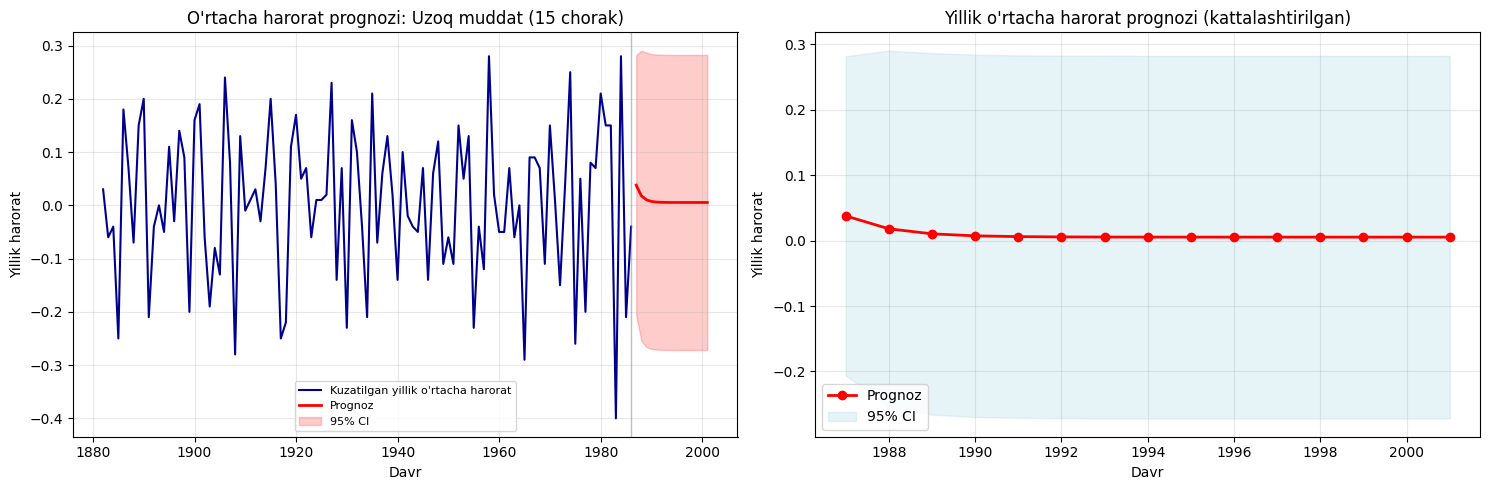

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].plot(dtepts.index, dtepts,
             linewidth=1.5, color='darkblue', label='Kuzatilgan yillik o\'rtacha harorat')
axes[0].plot(forecast_dates, forecast_mean,
             linewidth=2, color='red', label='Prognoz')
axes[0].fill_between(forecast_dates,
                     forecast_ci.iloc[:, 0],
                     forecast_ci.iloc[:, 1],
                     color='red', alpha=0.2, label='95% CI')
axes[0].axvline(x=tepts.index[-1], color='gray', linestyle='-', alpha=0.5, linewidth=1)

axes[0].set_title(f"O\'rtacha harorat prognozi: {selected_horizon} ({h} chorak)", fontsize=12)
axes[0].set_xlabel("Davr")
axes[0].set_ylabel("Yillik harorat")
axes[0].legend(loc='lower center', fontsize = 8)
axes[0].grid(True, alpha=0.3)



axes[1].plot(forecast_dates, forecast_mean, 'ro-', linewidth=2, label='Prognoz')
axes[1].fill_between(forecast_dates,
                      forecast_ci.iloc[:, 0],
                      forecast_ci.iloc[:, 1],
                      color='lightblue', alpha=0.3, label='95% CI')

axes[1].set_title(f"Yillik o\'rtacha harorat prognozi (kattalashtirilgan)", fontsize=12)
axes[1].set_xlabel("Davr")
axes[1].set_ylabel("Yillik harorat")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()